In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [4]:
cd C:\Users\tr432\Downloads\Figures_GutLungAxis\yes0\core-metrics-results-20731

C:\Users\tr432\Downloads\Figures_GutLungAxis\yes0\core-metrics-results-20731


In [5]:
## '#SampleID' 열 & 'Group' 열 있어야됨
meta = pd.read_csv('../RUN45_Metadata_GutLungAxis.txt', sep='\t')

## pcoa.qza export하면 생기는 ordination.txt 파일 그대로 가져다 쓰면됨
df_uw = pd.read_csv('unweighted_unifrac_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_w = pd.read_csv('weighted_unifrac_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_bray = pd.read_csv('bray_curtis_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_jaccard = pd.read_csv('jaccard_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))


mapping1 = meta.set_index('#SampleID')['Group']
mapping2 = meta.set_index('#SampleID')['SamplingWeek']
mapping3 = meta.set_index('#SampleID')['Group+SamplingWeek']
df_uw['Site1'] = df_uw['Site'].map(mapping1)
df_uw['Site2'] = df_uw['Site'].map(mapping2)
df_uw['Site3'] = df_uw['Site'].map(mapping3)
df_uw = df_uw.dropna(subset=['Site1', 'Site2', 'Site3'])
df_uw.columns = ['Site', 'PC1', 'PC2', 'Group', 'SamplingWeek', 'Group+SamplingWeek']

mapping1 = meta.set_index('#SampleID')['Group']
mapping2 = meta.set_index('#SampleID')['SamplingWeek']
df_w['Site1'] = df_w['Site'].map(mapping1)
df_w['Site2'] = df_w['Site'].map(mapping2)
df_w['Site3'] = df_w['Site'].map(mapping3)
df_w = df_w.dropna(subset=['Site1', 'Site2', 'Site3'])
df_w.columns = ['Site', 'PC1', 'PC2', 'Group', 'SamplingWeek', 'Group+SamplingWeek']

mapping1 = meta.set_index('#SampleID')['Group']
mapping2 = meta.set_index('#SampleID')['SamplingWeek']
mapping3 = meta.set_index('#SampleID')['Group+SamplingWeek']
df_bray['Site1'] = df_bray['Site'].map(mapping1)
df_bray['Site2'] = df_bray['Site'].map(mapping2)
df_bray['Site3'] = df_bray['Site'].map(mapping3)
df_bray = df_bray.dropna(subset=['Site1', 'Site2', 'Site3'])
df_bray.columns = ['Site', 'PC1', 'PC2', 'Group', 'SamplingWeek', 'Group+SamplingWeek']

mapping1 = meta.set_index('#SampleID')['Group']
mapping2 = meta.set_index('#SampleID')['SamplingWeek']
mapping3 = meta.set_index('#SampleID')['Group+SamplingWeek']
df_jaccard['Site1'] = df_jaccard['Site'].map(mapping1)
df_jaccard['Site2'] = df_jaccard['Site'].map(mapping2)
df_jaccard['Site3'] = df_jaccard['Site'].map(mapping3)
df_jaccard = df_jaccard.dropna(subset=['Site1', 'Site2', 'Site3'])
df_jaccard.columns = ['Site', 'PC1', 'PC2', 'Group', 'SamplingWeek', 'Group+SamplingWeek']

print(meta.head(3))
print(df_uw.head(3))
print(df_w.head(3))
print(df_bray.head(3))
print(df_jaccard.head(3))

  #SampleID subject    Subject_ID ExpNo MouseNo MouseNo2     MouseStrain Sex  \
0    C01-1w  C01-1w  Exp1_C1-2_1w  Exp1    C1-2      C01  C57BL/6NCrlOri   M   
1    C01-2w  C01-2w  Exp1_C1-2_2w  Exp1    C1-2      C01  C57BL/6NCrlOri   M   
2    C02-1w  C02-1w  Exp1_C2-1_1w  Exp1    C2-1      C02  C57BL/6NCrlOri   M   

  Age CageNo  ... SacrificeWeek ExpNo+Group ExpNo+SamplingWeek  \
0  8W     C1  ...         Week2    Exp1_Con         Exp1_Week1   
1  9W     C1  ...         Week2    Exp1_Con         Exp1_Week2   
2  8W     C2  ...         Week2    Exp1_Con         Exp1_Week1   

  Group+SamplingWeek ExpNo+Group+SamplingWeek BM_whole   BM_wbc Spleen   b.w  \
0          Con_Week1           Exp1_Con_Week1      NaN  1960000   64.0  22.8   
1          Con_Week2           Exp1_Con_Week2      NaN  1960000   64.0  22.8   
2          Con_Week1           Exp1_Con_Week1      NaN   970000  136.0  23.4   

  Spleen/b.w  
0       2.81  
1       2.81  
2       5.81  

[3 rows x 26 columns]
     Site 

In [6]:
## Beta-Diveristy PCoA plot의 Ellipse를 함수로 지정
def plot_confidence_ellipse(data, confidence_level=0.90):
    # 중심점 계산
    mean_x, mean_y = np.mean(data, axis=0)
    
    # 공분산 행렬 계산
    cov_matrix = np.cov(data, rowvar=False)
    
    # 고유값 분해
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    
    # 신뢰도 수준 스케일링
    # 90% 신뢰 구간을 위해 chi-square 값의 제곱근을 사용 (2차원에서는 약 4.605)
    if confidence_level == 0.95 :
        chi_square_val = 5.991
    elif confidence_level == 0.90 :
        chi_square_val = 4.605
    elif confidence_level == 0.8 :
        chi_square_val = 3.219
    else:
        raise ValueError('CI')

    scale = np.sqrt(chi_square_val)
    
    # 반지름 계산
    width, height = 2 * scale * np.sqrt(eigvals)
    
    # 타원의 회전각 계산 (라디안에서 도 단위로 변환)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    return (mean_x, mean_y), width, height, angle

def cal_ellipse(data, group_name, component1='Component1', componet2='Component2', cl=0.9):
    data = data[data['Group+SamplingWeek'] == group_name]
    data = data[[component1, componet2]].values

    (mean_x, mean_y), width, height, angle = plot_confidence_ellipse(data, confidence_level=cl)

    return (mean_x, mean_y), width, height, angle

In [7]:
## Group 종류 확인
print(df_uw.Group.unique())
print(df_uw.SamplingWeek.unique())
print(df_uw['Group+SamplingWeek'].unique())

print(df_w.Group.unique())
print(df_w.SamplingWeek.unique())
print(df_w['Group+SamplingWeek'].unique())

print(df_bray.Group.unique())
print(df_bray.SamplingWeek.unique())
print(df_bray['Group+SamplingWeek'].unique())

print(df_jaccard.Group.unique())
print(df_jaccard.SamplingWeek.unique())
print(df_jaccard['Group+SamplingWeek'].unique())

['Control' 'VNAM']
['Week1' 'Week2' 'Week0']
['Con_Week1' 'Con_Week2' 'Con_Week0' 'VNAM_Week1' 'VNAM_Week2'
 'VNAM_Week0']
['Control' 'VNAM']
['Week1' 'Week2' 'Week0']
['Con_Week1' 'Con_Week2' 'Con_Week0' 'VNAM_Week1' 'VNAM_Week2'
 'VNAM_Week0']
['Control' 'VNAM']
['Week1' 'Week2' 'Week0']
['Con_Week1' 'Con_Week2' 'Con_Week0' 'VNAM_Week1' 'VNAM_Week2'
 'VNAM_Week0']
['Control' 'VNAM']
['Week1' 'Week2' 'Week0']
['Con_Week1' 'Con_Week2' 'Con_Week0' 'VNAM_Week1' 'VNAM_Week2'
 'VNAM_Week0']


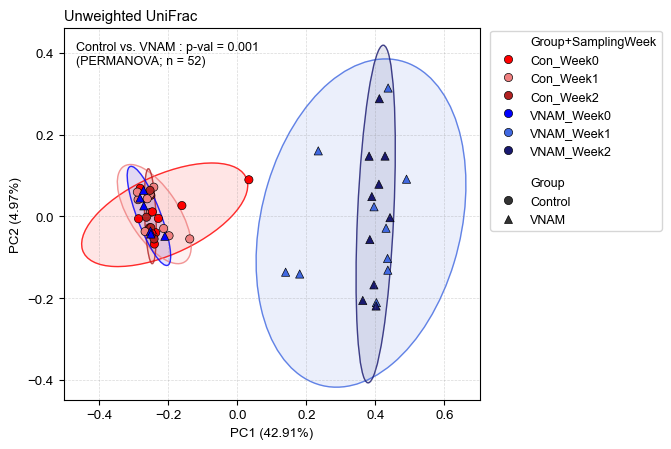

In [8]:
## Unweighted UniFrac


palette = ['red', 'lightcoral', 'firebrick', 'blue', 'royalblue', 'midnightblue']  ## 아래의 is_ellipse에서 지정한 색 순서랑 일치해야됨

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_uw


if is_ellipse:
    alpha=0.1  ## ellipse 내부 색 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='red', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='lightcoral', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='blue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='midnightblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)


    alpha=0.8  ## ellipse 테두리 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)


alpha = 1  ## 마커 투명도
order = ["Con_Week0", "Con_Week1", "Con_Week2", "VNAM_Week0", "VNAM_Week1", "VNAM_Week2"]
markers = {"Control": "o", "VNAM": "^"}  # Edit: Group 모양

sns.scatterplot(
    data=data, x='PC1', y='PC2',
    hue='Group+SamplingWeek', hue_order=order, palette=palette,
    style='Group', style_order=['Control', 'VNAM'], markers=markers,  ## 마커 모양 지정하는 부분. 이 부분 주석처리하면 마커 모양 같아짐.
    s=marker_size, alpha=alpha, edgecolor='k'
)


prop = pd.read_csv('unweighted_unifrac_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))  #Edit
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Unweighted UniFrac', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9)  ## loc='upper right' 로 바꾸면 legend가 plot 안으로 들어감
    for t in legend1.get_texts():
        if t.get_text() == 'Group':
            t.set_text('\nGroup')  ## 간격 더 키우려면 '\n\nGroup'
    label = f'Control vs. VNAM : p-val = 0.001\n(PERMANOVA; n = {df_uw.shape[0]})'  #Edit: p-value 값 바꾸고 df 이름 바꾸기
    legend2 = plt.legend([], [], title=label, loc='upper left', frameon=False, title_fontsize=9)  #Edit: loc 위치 적절하게 조절
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.8, 0.5)
#    plt.ylim(-0.5, 0.45)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../../uw_Group-based_diffshape.tiff', dpi=300, bbox_inches='tight')  ## bbox_inches='tight' 은 bbox_to_anchor=(1.01, 1.01) 때문에 legend가 잘리는걸 방지해줌

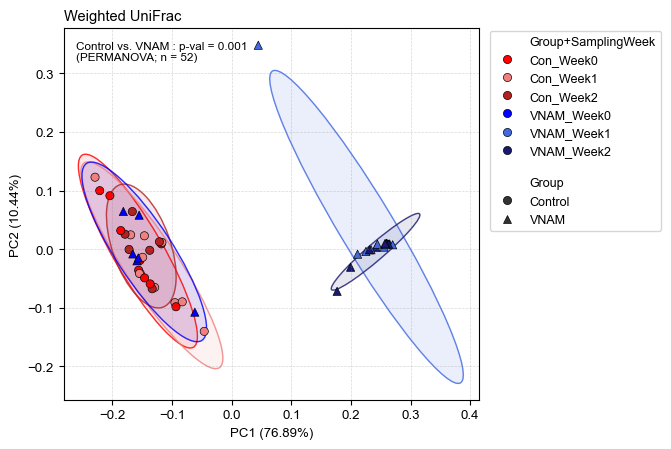

In [9]:
## Weighted UniFrac


palette = ['red', 'lightcoral', 'firebrick', 'blue', 'royalblue', 'midnightblue']  ## 아래의 is_ellipse에서 지정한 색 순서랑 일치해야됨

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_w


if is_ellipse:
    alpha=0.1  ## ellipse 내부 색 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='red', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='lightcoral', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='blue', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='midnightblue', alpha=alpha)
    ax.add_patch(ellipse)


    alpha=0.8  ## ellipse 테두리 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='none', alpha=alpha, linestyle='-')
    ax.add_patch(ellipse)


alpha = 1  ## 마커 투명도
order = ["Con_Week0", "Con_Week1", "Con_Week2", "VNAM_Week0", "VNAM_Week1", "VNAM_Week2"]
markers = {"Control": "o", "VNAM": "^"}  # Edit: Group 모양

sns.scatterplot(
    data=data, x='PC1', y='PC2',
    hue='Group+SamplingWeek', hue_order=order, palette=palette,
    style='Group', style_order=['Control', 'VNAM'], markers=markers,
    s=marker_size, alpha=alpha, edgecolor='k'
)


prop = pd.read_csv('weighted_unifrac_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Weighted UniFrac', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9)  ## loc='upper right' 로 바꾸면 legend가 plot 안으로 들어감
    # 섹션( Group+SamplingWeek vs Group ) 사이 간격 만들기
    for t in legend1.get_texts():
        if t.get_text() == 'Group':
            t.set_text('\nGroup')  ## 간격 더 키우려면 '\n\nGroup'
    label = f'Control vs. VNAM : p-val = 0.001\n(PERMANOVA; n = {df_w.shape[0]})'  #Edit: p-value 값 바꾸고 df 이름 바꾸기
    legend2 = plt.legend([], [], title=label, loc='upper left', frameon=False, title_fontsize=8.5)  #Edit: loc 위치 적절하게 조절
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.8, 0.5)
#    plt.ylim(-0.5, 0.45)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../../w_Group-based_diffshape.tiff', dpi=300, bbox_inches='tight')

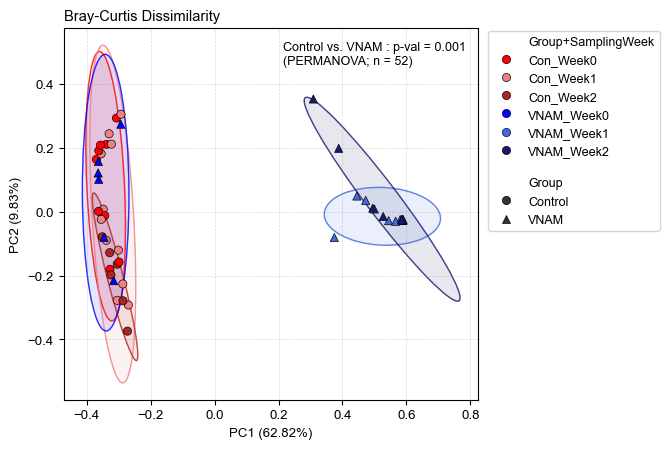

In [10]:
## Bray-Curtis Dissimilarity


palette = ['red', 'lightcoral', 'firebrick', 'blue', 'royalblue', 'midnightblue']  ## 아래의 is_ellipse에서 지정한 색 순서랑 일치해야됨

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_bray


if is_ellipse:
    alpha=0.1  ## ellipse 내부 색 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='red', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='lightcoral', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='blue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='midnightblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)


    alpha=0.8  ## ellipse 테두리 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)


alpha = 1  ## 마커 투명도
order = ["Con_Week0", "Con_Week1", "Con_Week2", "VNAM_Week0", "VNAM_Week1", "VNAM_Week2"]
markers = {"Control": "o", "VNAM": "^"}  # Edit: Group 모양

sns.scatterplot(
    data=data, x='PC1', y='PC2',
    hue='Group+SamplingWeek', hue_order=order, palette=palette,
    style='Group', style_order=['Control', 'VNAM'], markers=markers,  ## 마커 모양 지정하는 부분. 이 부분 주석처리하면 마커 모양 같아짐.
    s=marker_size, alpha=alpha, edgecolor='k'
)


prop = pd.read_csv('bray_curtis_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))  #Edit
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Bray-Curtis Dissimilarity', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9)  ## loc='upper right' 로 바꾸면 legend가 plot 안으로 들어감
    for t in legend1.get_texts():
        if t.get_text() == 'Group':
            t.set_text('\nGroup')  ## 간격 더 키우려면 '\n\nGroup'
    label = f'Control vs. VNAM : p-val = 0.001\n(PERMANOVA; n = {df_bray.shape[0]})'  #Edit: p-value 값 바꾸고 df 이름 바꾸기
    legend2 = plt.legend([], [], title=label, loc='upper right', frameon=False, title_fontsize=9)  #Edit: loc 위치 적절하게 조절
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.8, 0.5)
#    plt.ylim(-0.5, 0.45)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../../bray_Group-based_diffshape.tiff', dpi=300, bbox_inches='tight')  ## bbox_inches='tight' 은 bbox_to_anchor=(1.01, 1.01) 때문에 legend가 잘리는걸 방지해줌

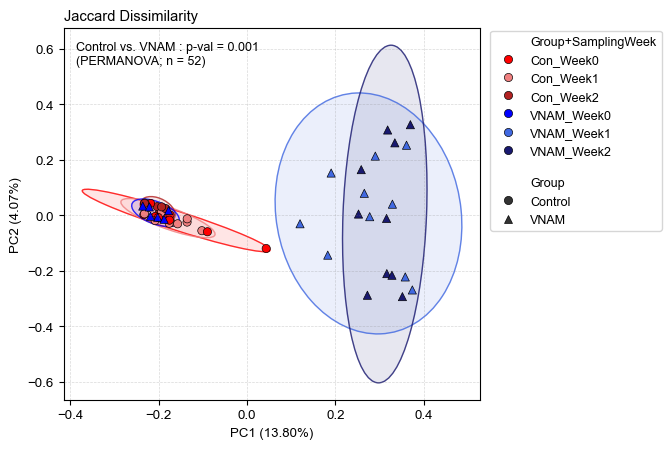

In [11]:
## Jaccard Dissimilarity


palette = ['red', 'lightcoral', 'firebrick', 'blue', 'royalblue', 'midnightblue']  ## 아래의 is_ellipse에서 지정한 색 순서랑 일치해야됨

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_jaccard


if is_ellipse:
    alpha=0.1  ## ellipse 내부 색 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='red', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='lightcoral', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='blue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='midnightblue', alpha=alpha)  #Edit
    ax.add_patch(ellipse)


    alpha=0.8  ## ellipse 테두리 투명도

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='red', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='lightcoral', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Con_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week0', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='blue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week1', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM_Week2', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='midnightblue', facecolor='none', alpha=alpha, linestyle='-')  #Edit
    ax.add_patch(ellipse)


alpha = 1  ## 마커 투명도
order = ["Con_Week0", "Con_Week1", "Con_Week2", "VNAM_Week0", "VNAM_Week1", "VNAM_Week2"]
markers = {"Control": "o", "VNAM": "^"}  # Edit: Group 모양

sns.scatterplot(
    data=data, x='PC1', y='PC2',
    hue='Group+SamplingWeek', hue_order=order, palette=palette,
    style='Group', style_order=['Control', 'VNAM'], markers=markers,  ## 마커 모양 지정하는 부분. 이 부분 주석처리하면 마커 모양 같아짐.
    s=marker_size, alpha=alpha, edgecolor='k'
)


prop = pd.read_csv('jaccard_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))  #Edit
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Jaccard Dissimilarity', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9)  ## loc='upper right' 로 바꾸면 legend가 plot 안으로 들어감
    for t in legend1.get_texts():
        if t.get_text() == 'Group':
            t.set_text('\nGroup')  ## 간격 더 키우려면 '\n\nGroup'
    label = f'Control vs. VNAM : p-val = 0.001\n(PERMANOVA; n = {df_bray.shape[0]})'  #Edit: p-value 값 바꾸고 df 이름 바꾸기
    legend2 = plt.legend([], [], title=label, loc='upper left', frameon=False, title_fontsize=9)  #Edit: loc 위치 적절하게 조절
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.8, 0.5)
#    plt.ylim(-0.5, 0.45)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../../jaccard_Group-based_diffshape.tiff', dpi=300, bbox_inches='tight')